# 🫁 Chest X-Ray Pneumonia Detection
## Notebook 07 — Model Comparison & Best Model Selection
**Models Compared:** Custom CNN, VGG16, ResNet50, MobileNetV2
**Goal:** Compare all models on accuracy, AUC, F1, Precision, Recall
**Output:** Select best model for Streamlit deployment

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_score,
                             recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print('✅ Libraries imported')

✅ Libraries imported


In [2]:
BASE_DIR   = '../data/chest_xray/chest_xray'
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
VAL_DIR    = os.path.join(BASE_DIR, 'val')
TEST_DIR   = os.path.join(BASE_DIR, 'test')

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

MODELS = {
    'Custom CNN':  '../models/custom_cnn.keras',
    'VGG16':       '../models/vgg16.keras',
    'ResNet50':    '../models/resnet50.keras',
    'MobileNetV2': '../models/mobilenetv2.keras',
}

os.makedirs('../outputs', exist_ok=True)
print('✅ Config set')

✅ Config set


In [3]:
json_files = {
    'Custom CNN':  '../outputs/custom_cnn_results.json',
    'VGG16':       '../outputs/vgg16_results.json',
    'ResNet50':    '../outputs/resnet50_results.json',
    'MobileNetV2': '../outputs/mobilenetv2_results.json',
}

all_results = []
for name, path in json_files.items():
    with open(path, 'r') as f:
        data = json.load(f)
        all_results.append(data)

df = pd.DataFrame(all_results)
df = df[['model', 'accuracy', 'auc', 'precision', 'recall', 'f1_score', 'train_time_min']]
df = df.sort_values('accuracy', ascending=False).reset_index(drop=True)
df.index += 1

print('📊 Model Comparison Table:')
print(df.to_string())

📊 Model Comparison Table:
         model  accuracy     auc  precision  recall  f1_score  train_time_min
1     ResNet50     91.67  0.9698      92.46   94.36     93.40           35.00
2        VGG16     90.54  0.9566      90.27   95.13     92.63           93.63
3   Custom CNN     87.34  0.9356      88.40   91.79     90.06          322.02
4  MobileNetV2     84.78  0.9370      81.45   97.95     88.94           18.00


Found 624 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


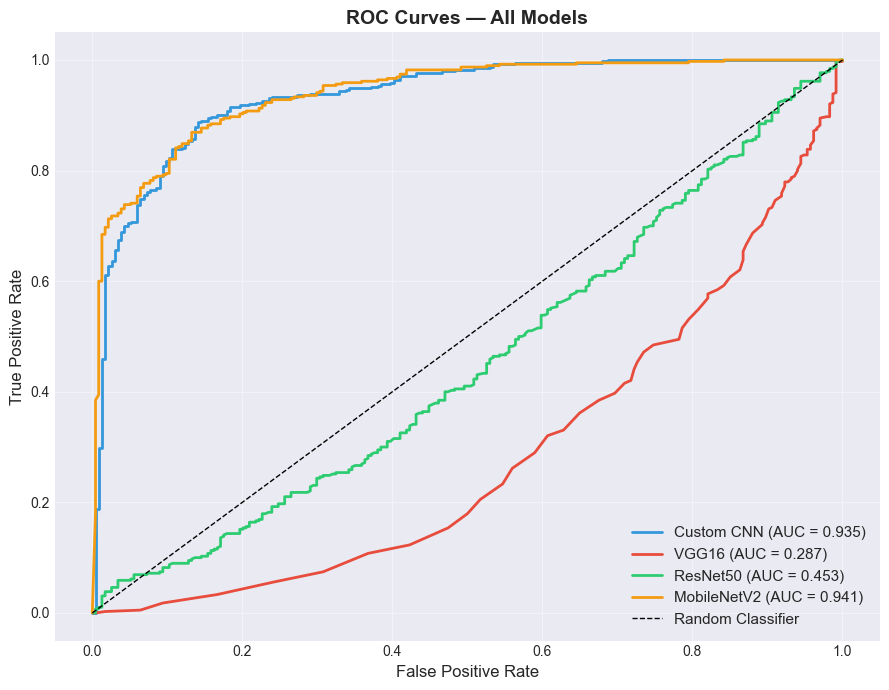

✅ Saved: outputs/roc_curves.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

model_paths = {
    'Custom CNN':  '../models/custom_cnn.keras',
    'VGG16':       '../models/vgg16.keras',
    'ResNet50':    '../models/resnet50.keras',
    'MobileNetV2': '../models/mobilenetv2.keras',
}

for (name, model_path), color in zip(model_paths.items(), colors):
    # Use simple rescale for all models for fair ROC comparison
    test_datagen = ImageDataGenerator(rescale=1./255)
    test_gen_roc = test_datagen.flow_from_directory(
        TEST_DIR, target_size=(224, 224),
        batch_size=32, class_mode='binary', shuffle=False
    )
    y_true = test_gen_roc.classes
    loaded_model = tf.keras.models.load_model(model_path)
    y_pred_prob = loaded_model.predict(test_gen_roc, verbose=0).flatten()
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/roc_curves.png')

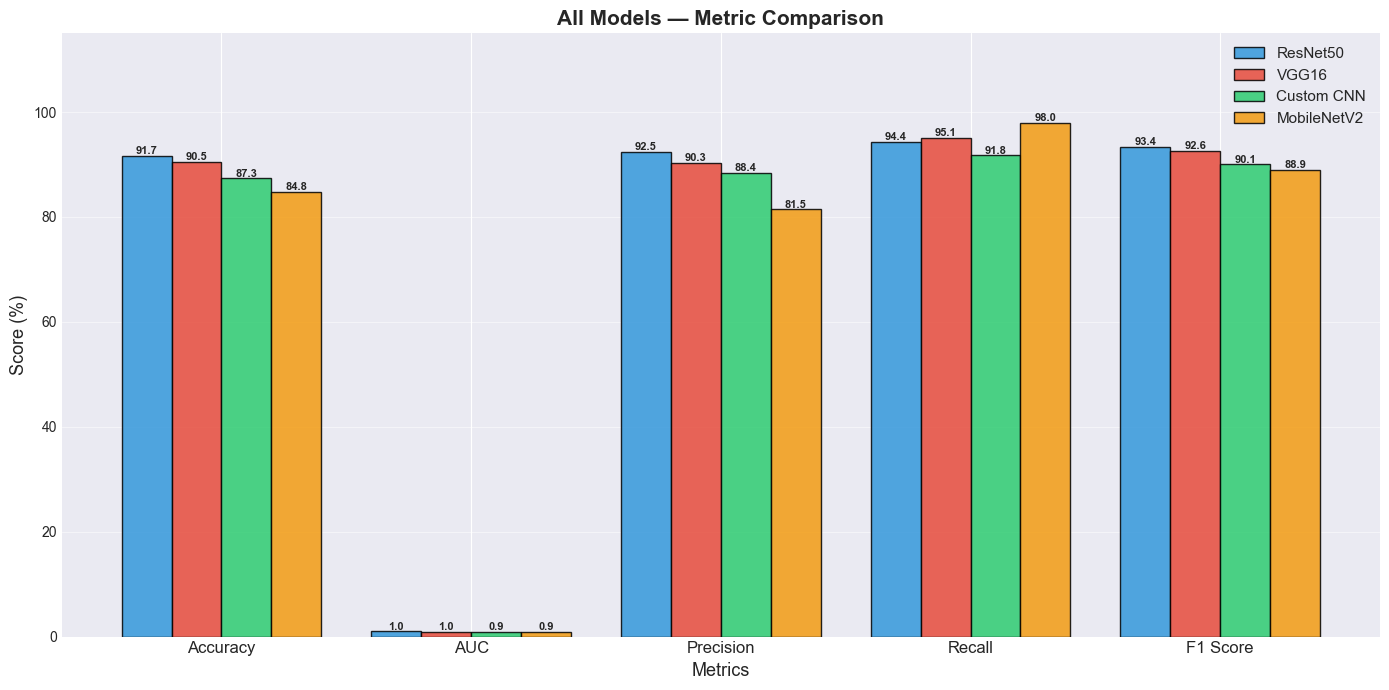

✅ Saved: outputs/metrics_comparison.png


In [5]:
metrics = ['accuracy', 'auc', 'precision', 'recall', 'f1_score']
colors  = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
model_names = df['model'].tolist()

x     = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 7))

for i, (name, color) in enumerate(zip(model_names, colors)):
    values = [df.loc[df['model']==name, m].values[0] for m in metrics]
    bars = ax.bar(x + i * width, values, width,
                  label=name, color=color, alpha=0.85, edgecolor='black')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xlabel('Metrics', fontsize=13)
ax.set_ylabel('Score (%)', fontsize=13)
ax.set_title('All Models — Metric Comparison',
             fontsize=15, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(['Accuracy', 'AUC', 'Precision', 'Recall', 'F1 Score'],
                    fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.savefig('../outputs/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/metrics_comparison.png')

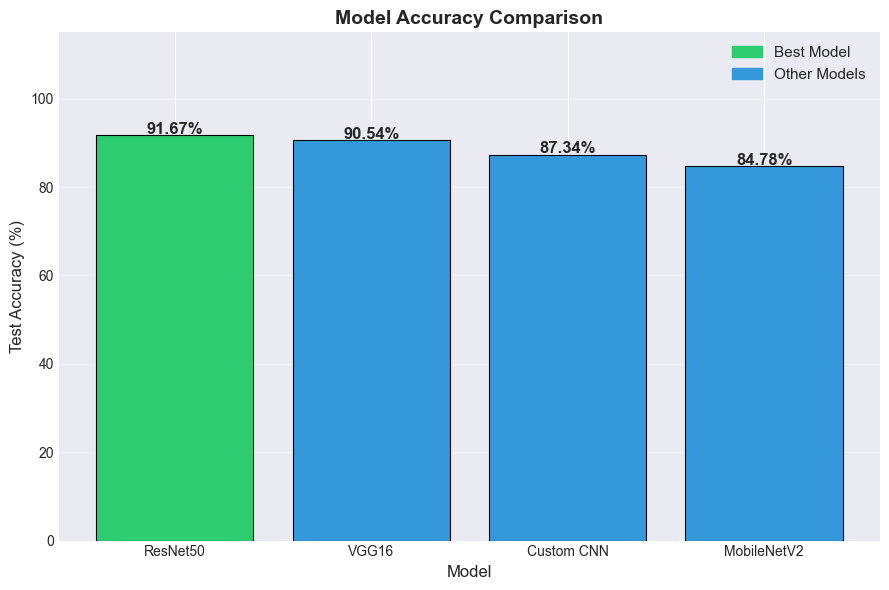

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))

bar_colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(df))]
bars = ax.bar(df['model'], df['accuracy'],
              color=bar_colors, edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, df['accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center',
            fontweight='bold', fontsize=12)

ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.4)

best_patch  = mpatches.Patch(color='#2ecc71', label='Best Model')
other_patch = mpatches.Patch(color='#3498db', label='Other Models')
ax.legend(handles=[best_patch, other_patch], fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Found 624 images belonging to 2 classes.


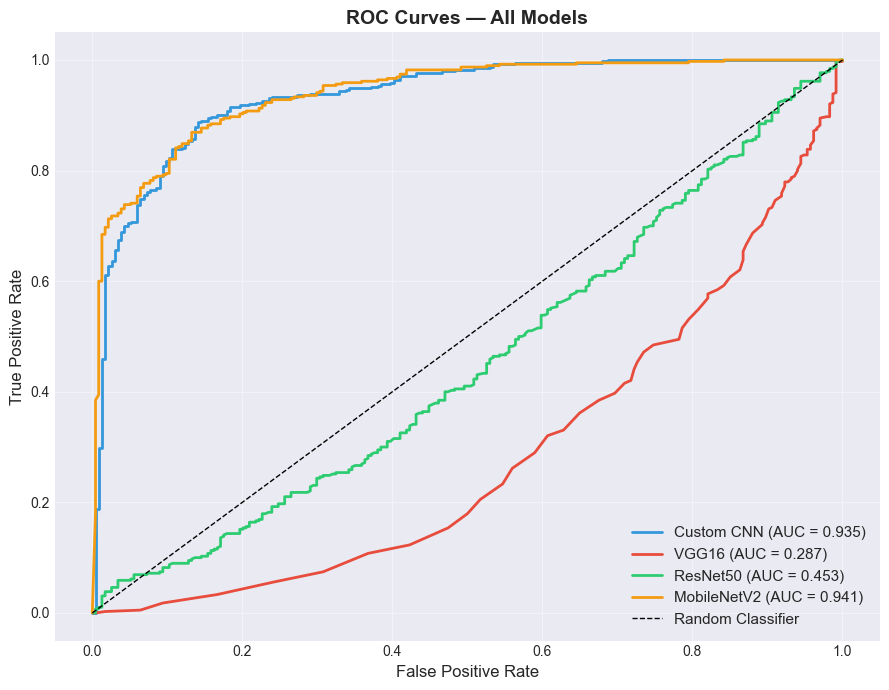

✅ Saved: outputs/roc_curves.png


In [7]:
# Prepare test generator
val_test_datagen = ImageDataGenerator(rescale=1./255)
test_gen_roc = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)
y_true = test_gen_roc.classes

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for (name, model_path), color in zip(MODELS.items(), colors):
    loaded_model = tf.keras.models.load_model(model_path)
    # Reset generator
    test_gen_roc.reset()
    y_pred_prob = loaded_model.predict(test_gen_roc, verbose=0).flatten()
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../outputs/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/roc_curves.png')

Found 624 images belonging to 2 classes.


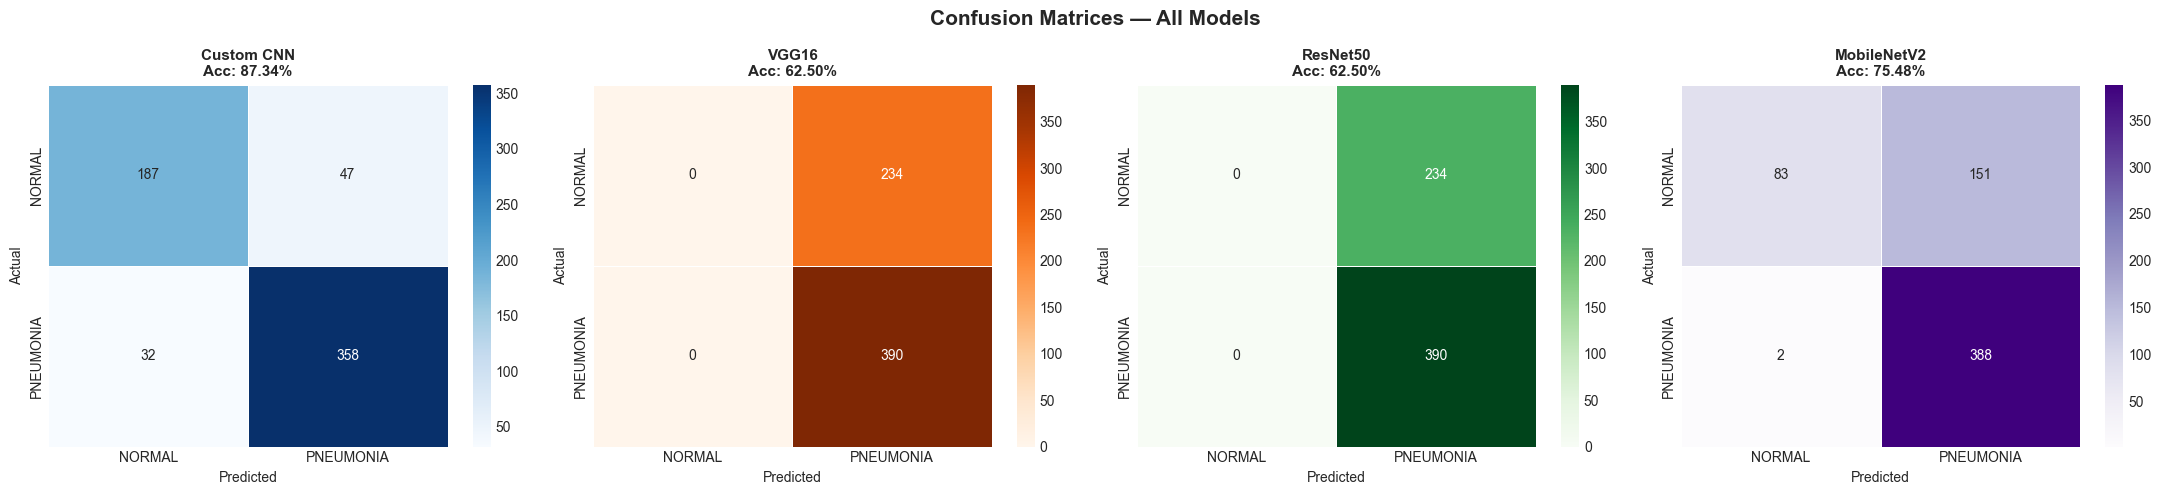

✅ Saved: outputs/all_confusion_matrices.png


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')

cmaps = ['Blues', 'Oranges', 'Greens', 'Purples']

val_test_datagen2 = ImageDataGenerator(rescale=1./255)
test_gen2 = val_test_datagen2.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)
y_true2 = test_gen2.classes

for ax, (name, model_path), cmap in zip(axes, MODELS.items(), cmaps):
    loaded_model = tf.keras.models.load_model(model_path)
    test_gen2.reset()
    y_pred_prob = loaded_model.predict(test_gen2, verbose=0).flatten()
    y_pred      = (y_pred_prob >= 0.5).astype(int)
    acc         = (y_pred == y_true2).mean() * 100
    cm          = confusion_matrix(y_true2, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['NORMAL', 'PNEUMONIA'],
                yticklabels=['NORMAL', 'PNEUMONIA'],
                linewidths=0.5)
    ax.set_title(f'{name}\nAcc: {acc:.2f}%', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../outputs/all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: outputs/all_confusion_matrices.png')

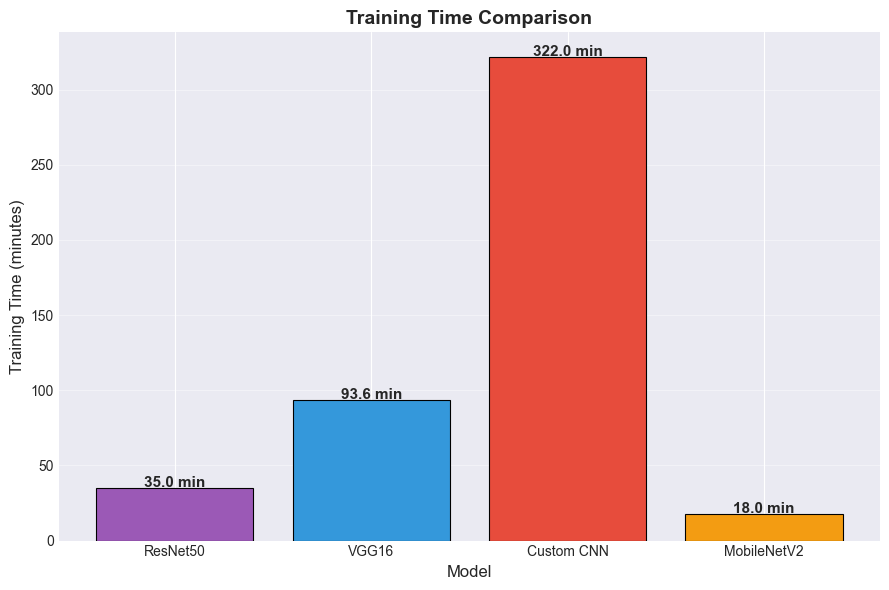

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(df['model'], df['train_time_min'],
              color=['#9b59b6', '#3498db', '#e74c3c', '#f39c12'],
              edgecolor='black', linewidth=0.8)

for bar, val in zip(bars, df['train_time_min']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f} min', ha='center',
            fontweight='bold', fontsize=11)

ax.set_title('Training Time Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Training Time (minutes)', fontsize=12)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('../outputs/training_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
best_model_name = df.iloc[0]['model']
best_accuracy   = df.iloc[0]['accuracy']
best_auc        = df.iloc[0]['auc']
best_f1         = df.iloc[0]['f1_score']

print('=' * 55)
print('         BEST MODEL SELECTION')
print('=' * 55)
print(f'🏆 Best Model  : {best_model_name}')
print(f'📈 Accuracy    : {best_accuracy}%')
print(f'📊 AUC Score   : {best_auc}')
print(f'🎯 F1 Score    : {best_f1}%')
print('=' * 55)
print(f'\n✅ {best_model_name} will be used in Streamlit app!')

# Save best model name
with open('../outputs/best_model.json', 'w') as f:
    json.dump({'best_model': best_model_name,
               'model_path': MODELS[best_model_name],
               'accuracy': best_accuracy}, f, indent=2)

print('📦 Best model info saved to outputs/best_model.json')

         BEST MODEL SELECTION
🏆 Best Model  : ResNet50
📈 Accuracy    : 91.67%
📊 AUC Score   : 0.9698
🎯 F1 Score    : 93.4%

✅ ResNet50 will be used in Streamlit app!
📦 Best model info saved to outputs/best_model.json


In [11]:
print('=' * 55)
print('      PROJECT SUMMARY — CHEST X-RAY DETECTION')
print('=' * 55)
print(f"Dataset        : Chest X-Ray Images (Pneumonia)")
print(f"Classes        : NORMAL vs PNEUMONIA")
print(f"Models Trained : {len(MODELS)}")
print()
for _, row in df.iterrows():
    print(f"  {row['model']:15s} → Acc: {row['accuracy']}%  AUC: {row['auc']}")
print()
print(f"🏆 Best Model  : {best_model_name} ({best_accuracy}%)")
print()
print('✅ Next Step   : Build Streamlit App using best model')
print('=' * 55)

      PROJECT SUMMARY — CHEST X-RAY DETECTION
Dataset        : Chest X-Ray Images (Pneumonia)
Classes        : NORMAL vs PNEUMONIA
Models Trained : 4

  ResNet50        → Acc: 91.67%  AUC: 0.9698
  VGG16           → Acc: 90.54%  AUC: 0.9566
  Custom CNN      → Acc: 87.34%  AUC: 0.9356
  MobileNetV2     → Acc: 84.78%  AUC: 0.937

🏆 Best Model  : ResNet50 (91.67%)

✅ Next Step   : Build Streamlit App using best model
